In [1]:
import pickle
from pathlib import Path

import jax
import jax.numpy as jnp
import equinox as eqx
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

CMAP = "inferno"   # swap for 'inferno', 'magma', 'Greys', etc.

In [2]:
CKPT = "runs_data/omkos-slotode/slot_ode_11_slots_euler_T5_dt1/checkpoints/best.eqx"
meta = pickle.load(open(CKPT.replace(".eqx", "_meta.pkl"), "rb"))
a = meta["args"]
resolution = (a["resolution"], a["resolution"])
key = jax.random.key(0)
from model import SlotODEModel
model = SlotODEModel(
    resolution=resolution,
    num_slots=a["num_slots"], slot_dim=a["slot_dim"],
    enc_hidden_dim=a.get("enc_hidden_dim", 64),
    num_iter=a["num_iter"], dt0=a.get("dt", 1.0),
    key=key,
)
model = eqx.tree_deserialise_leaves(CKPT, model)
print(f"Loaded T={model.slot_attention_ode.T}, dt={model.slot_attention_ode.dt0}")

Loaded T=5.0, dt=1.0


In [3]:
DATA_DIR = Path("CLEVR_64")
SCENE_IDS = {
    "3 objects": 424,
    "7 objects": 100,   # <-- swap with a good medium-complexity idx from select_scenes.py
    "9 objects": 32,
}
val_imgs = sorted((DATA_DIR / "images" / "val").glob("*.png"))

def load_img(idx):
    arr = np.array(Image.open(val_imgs[idx]).convert("RGB"), dtype=np.float32)
    return np.transpose(arr / 127.5 - 1.0, (2, 0, 1))

imgs_np = np.stack([load_img(i) for i in SCENE_IDS.values()])
images_jax = jnp.array(imgs_np)
print(f"Scenes loaded: {images_jax.shape}")

Scenes loaded: (3, 3, 64, 64)


In [4]:
# Use decoder alpha masks directly (sharper for small objects than attention weights).
def encode_kv(model, images):
    sa = model.slot_attention_ode
    enc = model.enc(images)
    feat_norm = jax.vmap(jax.vmap(sa.norm_input))(enc)
    feat = jax.vmap(jax.vmap(sa.fc_input))(feat_norm)
    k = jax.vmap(jax.vmap(sa.to_k))(feat)
    v = jax.vmap(jax.vmap(sa.to_v))(feat)
    return k, v

@eqx.filter_jit
def forward_with_traj(model, images, key):
    return model(images, key=key, return_traj=True)

key = jax.random.key(42)
recon, masks, slots_final, traj = forward_with_traj(model, images_jax, key)
masks_np = np.array(masks)   # [B, N_slots, H, W] decoder alpha masks
print(f"recon {recon.shape}, masks {masks_np.shape}, traj {traj.shape}")

E0427 19:11:57.391360   95540 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0427 19:11:58.155642   95553 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0427 19:11:58.272610   95540 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


recon (3, 3, 64, 64), masks (3, 11, 64, 64), traj (6, 3, 11, 64)


In [5]:
H = W = resolution[0]
N_slots = masks_np.shape[1]
att_spatial = masks_np  # kept variable name for downstream cells

def to_img(t):
    return np.clip((t.transpose(1, 2, 0) + 1) / 2, 0, 1)

def pick_active(att, k_top):
    peaks = att.max(axis=(1, 2))
    order = np.argsort(-peaks)
    return order[:k_top]

Active slots (K=7/11): [np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(8), np.int64(9), np.int64(10)]
Inactive slots (4/11): [0, 3, 6, 7]


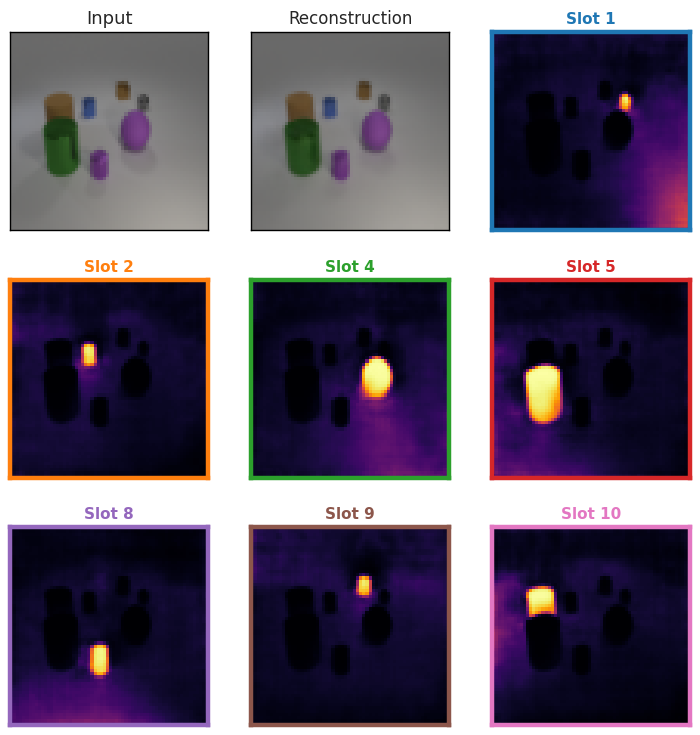

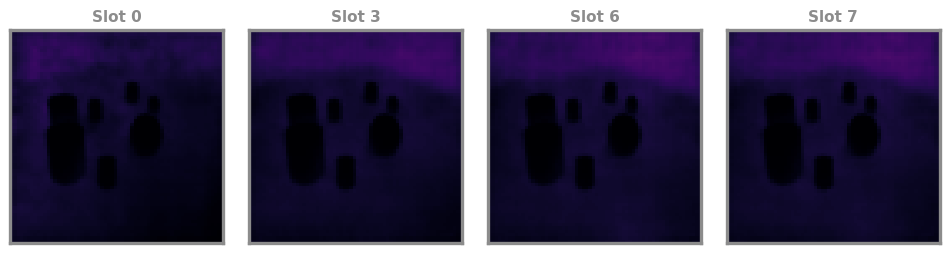

In [6]:
import math
import seaborn as sns
sns.set_theme(style="white", context="paper", font_scale=1.2)

PANEL = 3.0
LABEL = "7 objects"
K = 7
BORDER_LW = 3.2
INACTIVE_BORDER_LW = 2.4
INACTIVE_COLOR = "0.55"  # neutral gray for unused slots

def style_ax(ax, color="black", linewidth=1.0):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(color)
        spine.set_linewidth(linewidth)
    ax.set_xticks([]); ax.set_yticks([])

idx = SCENE_IDS[LABEL]
b = list(SCENE_IDS.values()).index(idx)

n_slots_total = int(att_spatial.shape[1])
active_slots = sorted(pick_active(att_spatial[b], K))[:K]
inactive_slots = [s for s in range(n_slots_total) if s not in set(active_slots)]

# Persistent color map shared with cell c7 for matched borders.
slot_palette = sns.color_palette("tab10", n_colors=max(K, 7))
slot_color_map = {s: slot_palette[i] for i, s in enumerate(active_slots)}
inactive_color_map = {s: INACTIVE_COLOR for s in inactive_slots}

print(f"Active slots (K={K}/{n_slots_total}): {active_slots}")
print(f"Inactive slots ({len(inactive_slots)}/{n_slots_total}): {inactive_slots}")

# --- Main 3x3: input, recon, selected slots (each with a colored border) ---
fig, axes = plt.subplots(3, 3, figsize=(PANEL * 3, PANEL * 3))
axes = axes.reshape(-1)

axes[0].imshow(to_img(imgs_np[b])); style_ax(axes[0])
axes[0].set_title("Input", fontsize=13)

axes[1].imshow(to_img(np.array(recon[b]))); style_ax(axes[1])
axes[1].set_title("Reconstruction", fontsize=12)

for j, s in enumerate(active_slots):
    ax = axes[2 + j]
    ax.imshow(att_spatial[b, s], cmap=CMAP, vmin=0, vmax=1)
    color = slot_color_map[s]
    style_ax(ax, color=color, linewidth=BORDER_LW)
    ax.set_title(f"Slot {s}", fontsize=11, color=color, weight="semibold")

for k in range(2 + len(active_slots), len(axes)):
    axes[k].axis("off")

plt.subplots_adjust(hspace=0.25, wspace=0.12)
plt.savefig("thesis_draft/figures/qualitative_attention.png", dpi=200, bbox_inches="tight")
plt.show()

# --- Separate plot: unselected slots (gray border to match active-slot styling) ---
if len(inactive_slots) > 0:
    n = len(inactive_slots)
    n_cols = min(4, n)
    n_rows = int(math.ceil(n / n_cols))

    fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(PANEL * n_cols, PANEL * n_rows))
    axes2 = np.array(axes2).reshape(-1)

    for j, s in enumerate(inactive_slots):
        ax = axes2[j]
        ax.imshow(att_spatial[b, s], cmap=CMAP, vmin=0, vmax=1)
        style_ax(ax, color=INACTIVE_COLOR, linewidth=INACTIVE_BORDER_LW)
        ax.set_title(f"Slot {s}", fontsize=11, color=INACTIVE_COLOR, weight="semibold")

    for j in range(n, len(axes2)):
        axes2[j].axis("off")

    plt.subplots_adjust(hspace=0.25, wspace=0.12)
    plt.savefig("thesis_draft/figures/qualitative_attention_inactive.png", dpi=200, bbox_inches="tight")
    plt.show()

In [7]:
# TIME EVOLUTION: integrate at fine dt, decode masks at each time step.
# Even with matched slot init, Euler at dt=1 (cell c3) and dt=0.1 (here) accumulate
# different discretization errors and routinely land at a *permuted* fixed point
# (slots are permutation-symmetric). After integrating, we Hungarian-match the
# fine-dt terminal state to c3's terminal state and reorder att_traj along the
# slot axis so slot indices line up with active_slots / slot_color_map from c5.
import diffrax
from scipy.optimize import linear_sum_assignment

SCENE_IDX = list(SCENE_IDS.values())[1]
b = list(SCENE_IDS.values()).index(SCENE_IDX)

DT_FINE = 0.1
T_MAX = float(model.slot_attention_ode.T)
ts_fine = jnp.arange(0.0, T_MAX + DT_FINE / 2, DT_FINE)

sa = model.slot_attention_ode

# Encode all three scenes (matches c3) and slice scene b's k, v.
k_all, v_all = encode_kv(model, images_jax)
k_s = k_all[b:b+1]
v_s = v_all[b:b+1]

# Initialize with the SAME key + batch=3 used in c3, then slice scene b.
slots_0_full = sa.initialize_slots(3, jax.random.key(42))   # [3, N, D]
slots_0 = slots_0_full[b:b+1]                                # [1, N, D]

sol = diffrax.diffeqsolve(
    diffrax.ODETerm(sa.slot_ode_func), diffrax.Euler(),
    t0=0.0, t1=T_MAX, dt0=DT_FINE, y0=slots_0, args=(k_s, v_s),
    saveat=diffrax.SaveAt(ts=ts_fine),
    stepsize_controller=diffrax.ConstantStepSize(),
    max_steps=int(T_MAX / DT_FINE) + 16,
)
traj_fine = sol.ys
print(f"fine trajectory {traj_fine.shape}, {len(ts_fine)} time points")

# --- Hungarian alignment of c6 slot indices to c3's permutation ---
S_c3 = np.array(traj[-1, b])         # [N, D] - cell c3 terminal slots (dt=1)
S_c6 = np.array(traj_fine[-1, 0])    # [N, D] - cell c6 terminal slots (dt=0.1)
dists = np.linalg.norm(S_c3[:, None, :] - S_c6[None, :, :], axis=-1)  # [N, N]
c3_rows, c6_cols = linear_sum_assignment(dists)
# Permutation: perm[c3_index] = corresponding c6 slot index
perm = np.zeros(att_spatial.shape[1], dtype=int)
for i, j in zip(c3_rows, c6_cols):
    perm[i] = j
print(f"slot permutation (c3 -> c6): {perm.tolist()}")
print(f"matched mean L2 distance: {dists[c3_rows, c6_cols].mean():.4f}")

@eqx.filter_jit
def decode_slots(model, slots):
    return model.dec(slots)

# Decode trajectory in c6 slot order, then reindex along slot axis.
att_traj_raw = []
for ti in range(traj_fine.shape[0]):
    _, masks_t = decode_slots(model, traj_fine[ti])
    att_traj_raw.append(np.array(masks_t)[0])
att_traj_raw = np.stack(att_traj_raw)            # [n_t, N, H, W] in c6 order

att_traj = att_traj_raw[:, perm, :, :]            # [n_t, N, H, W] in c3 / c5 order
print(f"att_traj {att_traj.shape}  (slot axis aligned to c3/c5)")

# Sanity: terminal mask of slot s in att_traj should match att_spatial[b, s].
sample_s = active_slots[0]
diff = float(np.linalg.norm(att_traj[-1, sample_s] - att_spatial[b, sample_s]))
print(f"terminal mask diff for slot {sample_s} (lower => better alignment): {diff:.4f}")

E0427 19:12:04.711412   95543 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


fine trajectory (51, 1, 11, 64), 51 time points
slot permutation (c3 -> c6): [9, 1, 0, 3, 7, 5, 6, 4, 8, 2, 10]
matched mean L2 distance: 6.3602
att_traj (51, 11, 64, 64)  (slot axis aligned to c3/c5)
terminal mask diff for slot 1 (lower => better alignment): 0.5960


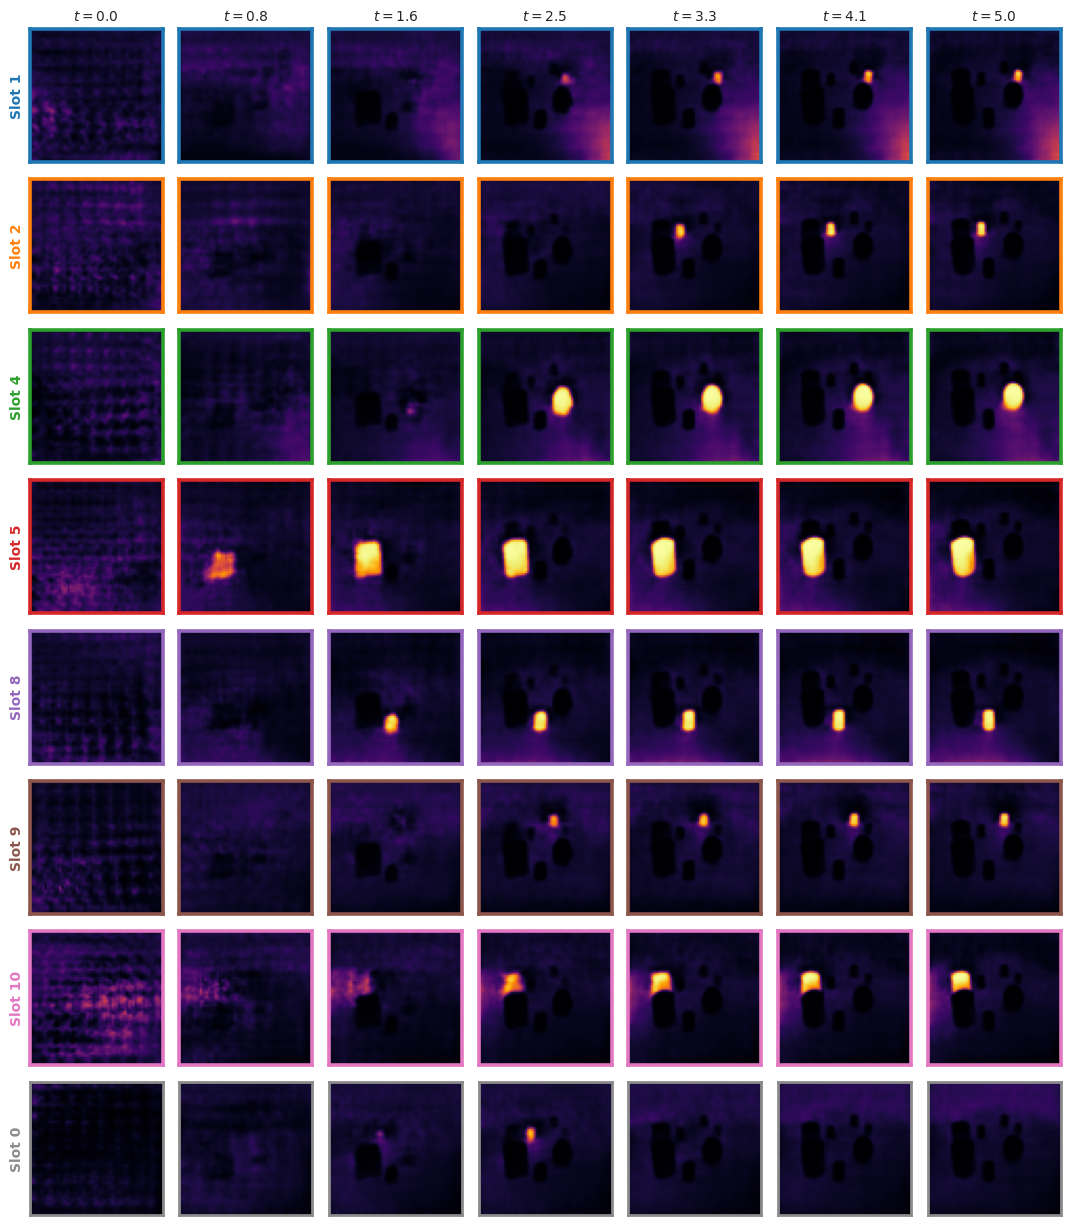

In [8]:
# Time-evolution mega plot. Reuses active_slots and slot_color_map from c5 so the
# slot indices, order, and border colors match the qualitative figure exactly.
# We also append one inactive slot at the bottom (gray border) to show the
# unused-slot collapse next to the bound trajectories.
INACTIVE_DEMO = inactive_slots[0] if len(inactive_slots) > 0 else None

active = list(active_slots)
rows = active + ([INACTIVE_DEMO] if INACTIVE_DEMO is not None else [])
row_colors = [slot_color_map[s] for s in active] + (
    [INACTIVE_COLOR] if INACTIVE_DEMO is not None else []
)
row_lws = [2.6] * len(active) + ([2.0] if INACTIVE_DEMO is not None else [])

TIME_IDXS = np.linspace(0, att_traj.shape[0] - 1, 7, dtype=int)
time_vals = np.array(ts_fine)[TIME_IDXS]

fig, axes = plt.subplots(len(rows), len(TIME_IDXS),
                         figsize=(1.55 * len(TIME_IDXS), 1.55 * len(rows)))
if len(rows) == 1:
    axes = axes[None, :]

for r, s in enumerate(rows):
    color = row_colors[r]
    lw = row_lws[r]
    is_inactive = (INACTIVE_DEMO is not None) and (r == len(rows) - 1) and (s == INACTIVE_DEMO)
    label = f"Slot {s}"
    for c, ti in enumerate(TIME_IDXS):
        ax = axes[r, c]
        ax.imshow(att_traj[ti, s], cmap=CMAP, vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color(color)
            spine.set_linewidth(lw)
        if r == 0:
            ax.set_title(f"$t={time_vals[c]:.1f}$", fontsize=10)
        if c == 0:
            ax.set_ylabel(label, fontsize=10, color=color, weight="semibold")

plt.tight_layout()
plt.savefig("thesis_draft/figures/attention_time_evolution.png", dpi=200, bbox_inches="tight")
plt.show()

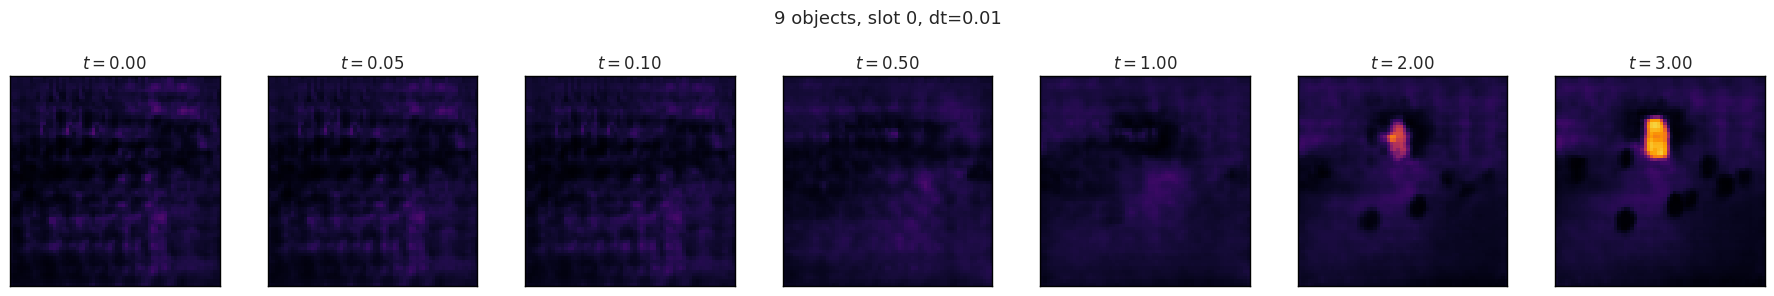

In [9]:
# INTERACTIVE: pick a scene, slot, fine dt, and specific time points to view.
SCENE_LABEL = "9 objects"
SLOT_IDX = 0
DT_FINE_PICK = 0.01
TIME_POINTS = [0.0, 0.05, 0.1, 0.5, 1.0, 2.0, 3.0]  # must lie in [0, T_MAX]

scene_idx = SCENE_IDS[SCENE_LABEL]
bb = list(SCENE_IDS.values()).index(scene_idx)

T_MAX_P = float(model.slot_attention_ode.T)
ts_pick = jnp.array([t for t in TIME_POINTS if 0.0 <= t <= T_MAX_P])

single = images_jax[bb:bb+1]
k_p, v_p = encode_kv(model, single)
slots_0p = model.slot_attention_ode.initialize_slots(1, jax.random.key(42))

sol_p = diffrax.diffeqsolve(
    diffrax.ODETerm(model.slot_attention_ode.slot_ode_func), diffrax.Euler(),
    t0=0.0, t1=T_MAX_P, dt0=DT_FINE_PICK, y0=slots_0p, args=(k_p, v_p),
    saveat=diffrax.SaveAt(ts=ts_pick),
    stepsize_controller=diffrax.ConstantStepSize(),
    max_steps=int(T_MAX_P / DT_FINE_PICK) + 32,
)

masks_pick = []
for ti in range(sol_p.ys.shape[0]):
    _, m_t = decode_slots(model, sol_p.ys[ti])
    masks_pick.append(np.array(m_t)[0, SLOT_IDX])
masks_pick = np.stack(masks_pick)

n = len(ts_pick)
fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 2.8))
if n == 1:
    axes = [axes]
for i, t in enumerate(np.array(ts_pick)):
    axes[i].imshow(masks_pick[i], cmap=CMAP, vmin=0, vmax=1)
    style_ax(axes[i])
    axes[i].set_title(f"$t={t:.2f}$", fontsize=12)
fig.suptitle(f"{SCENE_LABEL}, slot {SLOT_IDX}, dt={DT_FINE_PICK}", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

In [10]:
# GIF: continuous-time visualization of a slot's mask evolving from t=0 to T_MAX.
from matplotlib import animation
from IPython.display import HTML

GIF_SCENE = "9 objects"
GIF_SLOT = 0
GIF_DT = 0.01
FPS = 30
GIF_PATH = f"thesis_draft/figures/slot{GIF_SLOT}_{GIF_SCENE.replace(' ', '_')}.gif"

g_idx = SCENE_IDS[GIF_SCENE]
gb = list(SCENE_IDS.values()).index(g_idx)

T_G = float(model.slot_attention_ode.T)
ts_g = jnp.arange(0.0, T_G + GIF_DT / 2, GIF_DT)

k_g, v_g = encode_kv(model, images_jax[gb:gb+1])
slots_0g = model.slot_attention_ode.initialize_slots(1, jax.random.key(42))

sol_g = diffrax.diffeqsolve(
    diffrax.ODETerm(model.slot_attention_ode.slot_ode_func), diffrax.Euler(),
    t0=0.0, t1=T_G, dt0=GIF_DT, y0=slots_0g, args=(k_g, v_g),
    saveat=diffrax.SaveAt(ts=ts_g),
    stepsize_controller=diffrax.ConstantStepSize(),
    max_steps=int(T_G / GIF_DT) + 32,
)

print(f"decoding {sol_g.ys.shape[0]} frames...")
frames = []
for ti in range(sol_g.ys.shape[0]):
    _, m_t = decode_slots(model, sol_g.ys[ti])
    frames.append(np.array(m_t)[0, GIF_SLOT])
frames = np.stack(frames)

fig, (ax_in, ax) = plt.subplots(1, 2, figsize=(6.5, 3.2))
ax_in.imshow(to_img(imgs_np[gb])); style_ax(ax_in); ax_in.set_title("Input", fontsize=12)
im = ax.imshow(frames[0], cmap=CMAP, vmin=0, vmax=1)
style_ax(ax)
ttl = ax.set_title(f"Slot {GIF_SLOT}  $t=0.00$", fontsize=12)

def update(i):
    im.set_data(frames[i])
    ttl.set_text(f"Slot {GIF_SLOT}  $t={float(ts_g[i]):.2f}$")
    return im, ttl

anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=1000 / FPS, blit=False)
anim.save(GIF_PATH, writer=animation.PillowWriter(fps=FPS))
plt.close(fig)
print(f"wrote {GIF_PATH} ({len(frames)} frames @ {FPS}fps)")
HTML(f'<img src="{GIF_PATH}">')

decoding 501 frames...
wrote thesis_draft/figures/slot0_9_objects.gif (501 frames @ 30fps)
